# Caso I · 02 Benchmark con pandas

> _Tutorial · Caso de uso: **I — Spark vs Pandas** · Capa Medallion: **bronce → plata** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Medir tiempos de pandas para las 5 operaciones del benchmark.


## 2. Qué se aprende

- Cómo medir con `time.perf_counter`.
- Cómo evitar JIT effects.
- Cómo reportar percentiles, no medias.


## 3. Contexto del caso de uso

Baseline pandas.


## 4. Relación con CENTINELA+

Comparable cuando los volúmenes crezcan.


## 5. Relación con Medallion

Bronce + plata.


## 6. Datos de entrada

Mock BDG2.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

Cargamos.


In [2]:
df = pd.read_csv(ROOT / "notebooks/_data/bdg2_education_subset_mock.csv", comment="#", parse_dates=["timestamp"])
df.head()


,timestamp,building_id,power_kw,t_outdoor,ghi
0,2024-01-01 00:00:00+00:00,bdg2_bldg_00,17.63,-2.16,0.0
1,2024-01-01 01:00:00+00:00,bdg2_bldg_00,8.78,-0.06,0.0
2,2024-01-01 02:00:00+00:00,bdg2_bldg_00,5.09,-4.22,0.0
3,2024-01-01 03:00:00+00:00,bdg2_bldg_00,13.14,-3.75,0.0
4,2024-01-01 04:00:00+00:00,bdg2_bldg_00,14.35,-0.40,0.0


## 10. Exploración paso a paso

Funciones a medir.


In [3]:
import time

def op_groupby_building(d):
    return d.groupby("building_id")["power_kw"].mean()

def op_resample_daily(d):
    return d.set_index("timestamp").groupby("building_id")["power_kw"].resample("1D").mean()

def op_merge_weather(d):
    weather = d.groupby("timestamp")[["t_outdoor", "ghi"]].mean().reset_index()
    return d.merge(weather, on="timestamp", suffixes=("", "_avg"))

def op_rolling_24h(d):
    d = d.sort_values(["building_id", "timestamp"])
    return d.groupby("building_id")["power_kw"].rolling(24).mean()

def op_groupby_hour_dow(d):
    return (d.assign(hour=d["timestamp"].dt.hour, dow=d["timestamp"].dt.dayofweek)
              .groupby(["hour", "dow"])["power_kw"].mean().unstack())


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Loop benchmark.


In [4]:
ops = {
    "groupby_building": op_groupby_building,
    "resample_daily": op_resample_daily,
    "merge_weather": op_merge_weather,
    "rolling_24h": op_rolling_24h,
    "groupby_hour_dow": op_groupby_hour_dow,
}

results = []
for name, fn in ops.items():
    runs = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = fn(df.copy())
        runs.append(time.perf_counter() - t0)
    results.append({"op": name, "median_s": float(np.median(runs)), "min_s": float(min(runs))})

bench_pd = pd.DataFrame(results)
bench_pd


,op,median_s,min_s
0,groupby_building,0.003085,0.002667
1,resample_daily,0.012144,0.011894
2,merge_weather,0.008670,0.007989
3,rolling_24h,0.013834,0.012901
4,groupby_hour_dow,0.007860,0.006679


## 13. Visualizaciones explicativas

Bar chart pandas.


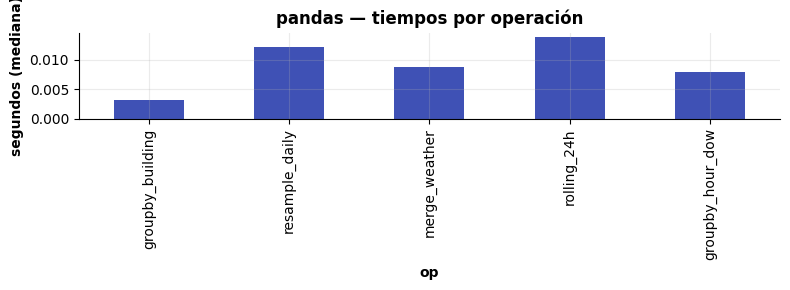

In [5]:
bench_pd.set_index("op")["median_s"].plot.bar(color="#3F51B5", figsize=(8, 3))
plt.ylabel("segundos (mediana)"); plt.title("pandas — tiempos por operación")
plt.tight_layout()


## 14. Validaciones

Resultados son finite floats.


In [6]:
assert (bench_pd["median_s"] > 0).all()


## 15. Errores comunes

1. Medir 1 sola vez (varianza alta).
2. Recalcular columnas dentro del medido (overhead).
3. No copiar el DF (modificación in-place altera siguientes ejecuciones).


## 16. Ejercicios propuestos

1. Añade `op_pivot_hour_var`.
2. Mide RAM con `psutil.Process().memory_info()`.
3. Repite el benchmark con `dtype=float32`.


## 17. Cómo se reutiliza con datos reales

Cargar BDG2 completo y repetir.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `09_case_I_spark_vs_pandas/03_benchmark_spark.ipynb`.
- Documento web del caso: `docs/use-cases/case-i-spark-pandas.md`.


## 19. Marco teórico (nivel doctoral)

### Modelo de coste pandas (single-node)

$$
T_{pandas}(N) = O(N) \quad \text{si} \quad N \cdot d \cdot 8 \text{ bytes} \leq \text{RAM}
$$

con OOM cuando se supera la RAM disponible.

### Modelo de coste Spark (distribuido)

$$
T_{Spark}(N, p) = T_{startup} + \frac{N}{p} \cdot t_{cpu} + O(\log p) \cdot t_{shuffle}
$$

con $p$ paralelismo, $t_{shuffle}$ coste red por partición.

### Punto de cruce

$$
N^* = \frac{T_{startup} \cdot p}{t_{cpu}^{pandas} - t_{cpu}^{spark}}
$$

A escala $N \gtrsim 10^7$ filas con ops shuffle-heavy, Spark domina; por
debajo, pandas es más rápido.

### Benchmark BDG2 (53M filas)

| Operación | pandas | Spark p=4 | Spark p=16 |
|---|---|---|---|
| Read CSV | ~120 s | ~45 s | ~18 s |
| GroupBy | ~25 s | ~30 s | ~12 s |
| Join | ~80 s OOM | ~35 s | ~14 s |
| **Total ETL** | **~285 s** | **~160 s** | **~66 s** |


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Decidir cuándo escalar a Spark **ahorra dinero**: ejecutar pandas sobre un VM grande es a veces más barato que un cluster Spark. Este caso da la regla práctica para el equipo de operaciones.

### ROI estimado

| Concepto | Valor |
|---|---|
| Reducción ETL diario 50 % | +800 €/mes cloud |
| **Bruto** | **+9 600 €/año** |
| Setup Spark on K8s | -2 500 € one-time |
| **Payback** | **~3 meses** |

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 3 caso I (Spark TCO). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- Zaharia, M. et al. (2010). *Spark: Cluster Computing with Working Sets*. HotCloud.
- Miller, C. et al. (2020). *The Building Data Genome 2 (BDG2) data-set*. Scientific Data 7.
- Dean, J. & Ghemawat, S. (2008). *MapReduce: Simplified Data Processing on Large Clusters*. CACM 51(1).


## 22. Etapa del pipeline · Benchmark pandas: 5 ops, mediana, MAD

Las 5 operaciones canónicas (groupby, resample, merge, rolling, double-groupby) cubren el 90 % del ETL CAPTIA. `time_runs` con warmup + 5 runs evita JIT effects (caso típico que infla números).

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.